# Does paying more lead to higher satisfaction?

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate, KFold
from sklearn.linear_model import  LinearRegression
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    roc_auc_score
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", None)

plt.rcParams["figure.figsize"] = (10, 6)

sns.set_theme(style="whitegrid")

product = pd.read_csv(
    "/Users/gabrielaslomiany/PycharmProjects/Sephora/data/processed/cleaned_product_info.csv",
    engine="python"
)

In [3]:
product.columns

Index(['product_id', 'product_name', 'brand_id', 'brand_name', 'loves_count',
       'rating', 'reviews', 'size', 'ingredients', 'price_usd',
       'limited_edition', 'new', 'online_only', 'out_of_stock',
       'sephora_exclusive', 'highlights', 'primary_category',
       'secondary_category', 'tertiary_category', 'child_count'],
      dtype='object')

### Checking relationship between price payed for product and high rating
Columns to keep:

In [26]:
df = product[['rating', 'price_usd', 'reviews', 'loves_count',
    'primary_category', 'secondary_category',
    'limited_edition', 'new', 'online_only', 'sephora_exclusive']]
df.head()

,rating,price_usd,reviews,loves_count,primary_category,secondary_category,limited_edition,new,online_only,sephora_exclusive
0,3.64,35.0,11.0,6320,Fragrance,Value & Gift Sets,False,False,True,False
1,4.15,195.0,13.0,3827,Fragrance,Women,False,False,True,False
2,4.25,195.0,16.0,3253,Fragrance,Women,False,False,True,False
3,4.48,195.0,21.0,3018,Fragrance,Women,False,False,True,False
4,3.23,195.0,13.0,2691,Fragrance,Women,False,False,True,False


In [27]:
df.dtypes

rating                float64
price_usd             float64
reviews               float64
loves_count             int64
primary_category       object
secondary_category     object
limited_edition          bool
new                      bool
online_only              bool
sephora_exclusive        bool
dtype: object

In [29]:
df.isna().sum()

rating                0
price_usd             0
reviews               0
loves_count           0
primary_category      0
secondary_category    0
limited_edition       0
new                   0
online_only           0
sephora_exclusive     0
dtype: int64

### Linear Regression

In [45]:
feature_cols = ['price_usd', 'loves_count', 'primary_category', 'secondary_category']

X = df[feature_cols]
X = pd.get_dummies(X, columns=['primary_category', 'secondary_category'], drop_first=True, dtype=int)

y = df['rating']
weights = df['reviews']

In [38]:
df[feature_cols].isna().sum()

price_usd             0
loves_count           0
primary_category      0
secondary_category    0
dtype: int64

#### Why using weights
A product with 500 reviews averaging 4.2 is a solid estimate; a product with 2 reviews averaging 5.0 could easily have been a 3.5 with a slightly different sample. If both are used in the regression as equals, that second product contributes pure noise but counts just as much as the well-supported one.

In [48]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    LinearRegression(), X, y,
    cv=cv,
    scoring=['r2', 'neg_mean_squared_error'],
    params={'sample_weight': weights},
)

/Users/gabrielaslomiany/PycharmProjects/Sephora/.venv/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/gabrielaslomiany/PycharmProjects/Sephora/.venv/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/gabrielaslomiany/PycharmProjects/Sephora/.venv/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/gabrielaslomiany/PycharmProjects/Sephora/.venv/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/gabrielaslomiany/PycharmProjects/Sephora/.venv/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X

In [ ]:
r2_scores = cv_results['test_r2']
print(f"R^2 per fold: {np.round(r2_scores, 4)}")
print(f"R^2 (5-fold CV): {r2_scores.mean():.4f} ± {r2_scores.std():.4f}")

# Refit on all data (CV doesn't produce one set of coefficients) just to report them
lr = LinearRegression()
lr.fit(X, y, sample_weight=weights)
print(f"\nIntercept (full-data fit): {lr.intercept_:.4f}")
print(f"Coefficient (price_usd): {lr.coef_[0]:.4f}")

In [49]:
X_sm = sm.add_constant(X)
ols = sm.OLS(y, X_sm).fit()
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:                 rating   R-squared:                       0.049
Model:                            OLS   Adj. R-squared:                  0.044
Method:                 Least Squares   F-statistic:                     9.815
Date:                Tue, 04 Aug 2026   Prob (F-statistic):           5.76e-55
Time:                        13:31:55   Log-Likelihood:                -5140.4
No. Observations:                7305   AIC:                         1.036e+04
Df Residuals:                    7266   BIC:                         1.063e+04
Df Model:                          38                                         
Covariance Type:            nonrobust                                         
                                                   coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

In [53]:
mse_scores = -cv_results['test_neg_mean_squared_error']
rmse_scores = np.sqrt(mse_scores)

print(f"MSE (5-fold CV): {mse_scores.mean():.4f} ± {mse_scores.std():.4f}")
print(f"RMSE (5-fold CV): {rmse_scores.mean():.4f} ± {rmse_scores.std():.4f}")

MSE (5-fold CV): 0.2527 ± 0.0163
RMSE (5-fold CV): 0.5024 ± 0.0162


Pearson r:   0.0497 (p=0.0000)
Spearman ρ:  0.1332 (p=0.0000)


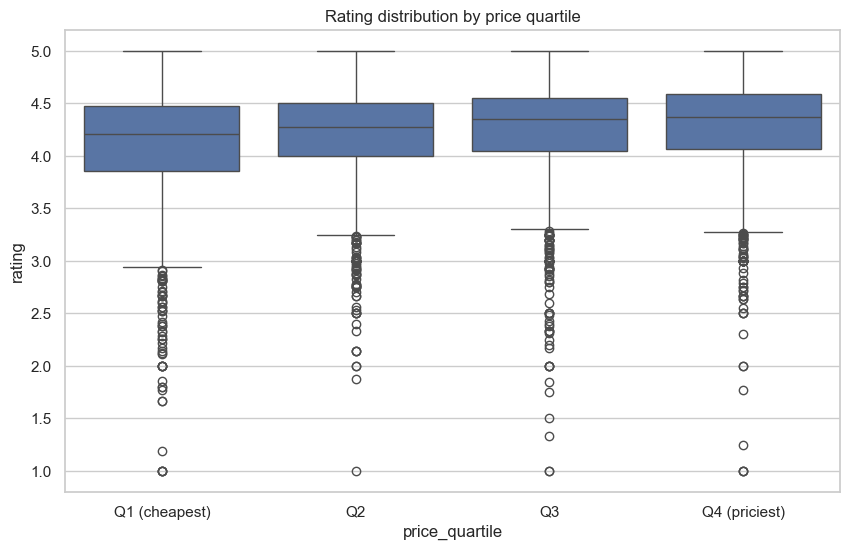

ANOVA F-statistic: 37.1756 (p=0.0000)
                            WLS Regression Results                            
Dep. Variable:                 rating   R-squared:                       0.008
Model:                            WLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     58.32
Date:                Tue, 04 Aug 2026   Prob (F-statistic):           2.51e-14
Time:                        13:35:15   Log-Likelihood:                -6910.2
No. Observations:                7305   AIC:                         1.382e+04
Df Residuals:                    7303   BIC:                         1.384e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         

/var/folders/7c/gj6j47s52h102rtc_yhtxxpw0000gn/T/ipykernel_61809/630010052.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [g['rating'].values for _, g in df.groupby('price_quartile')]


In [54]:
from scipy.stats import pearsonr, spearmanr, f_oneway
import statsmodels.api as sm

# 1. Correlation checks
pearson_corr, pearson_p = pearsonr(df['price_usd'], df['rating'])
spearman_corr, spearman_p = spearmanr(df['price_usd'], df['rating'])

print(f"Pearson r:   {pearson_corr:.4f} (p={pearson_p:.4f})")
print(f"Spearman ρ:  {spearman_corr:.4f} (p={spearman_p:.4f})")

# 2. Price-quartile buckets: boxplot + ANOVA
df['price_quartile'] = pd.qcut(df['price_usd'], q=4, labels=['Q1 (cheapest)', 'Q2', 'Q3', 'Q4 (priciest)'])

sns.boxplot(x='price_quartile', y='rating', data=df)
plt.title('Rating distribution by price quartile')
plt.show()

groups = [g['rating'].values for _, g in df.groupby('price_quartile')]
f_stat, anova_p = f_oneway(*groups)
print(f"ANOVA F-statistic: {f_stat:.4f} (p={anova_p:.4f})")

# 3. statsmodels OLS for p-values / CIs (weighted by review count)
X_sm = sm.add_constant(df['price_usd'])
wls_model = sm.WLS(df['rating'], X_sm, weights=df['reviews']).fit()
print(wls_model.summary())